In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("thyroid_dataset.csv")
x=df.drop("Outlier_label",axis=1)  ## out goal is to  detect the outiler ..i.e we are removing outlier label
y=df["Outlier_label"]


In [5]:
#scaling
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [7]:
from sklearn.ensemble import IsolationForest
isf=IsolationForest(n_estimators=100,contamination="auto",random_state=42)
labels=isf.fit_predict(x_scaled)


array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

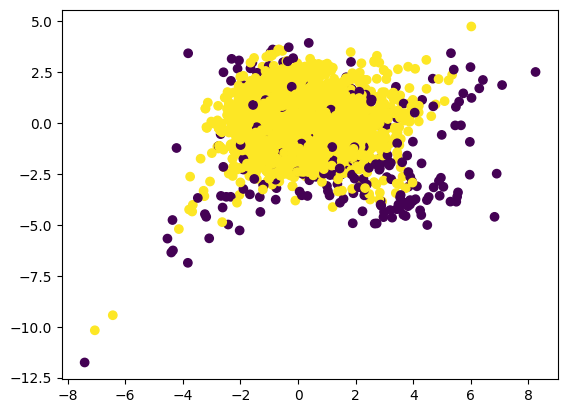

In [9]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
## violets points are outliers..
## there are some yellow points far way looking like outliers..see PCA might loose some data during process right..
##so there can be some inaccuracy..majority is visualised correctly

In [10]:
import numpy as np
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("Outliers : ",n_outliers)
print("Noraml : ",n_normal)

Outliers :  275
Noraml :  6641


In [ ]:
## actaully it is mentioned as 250 outliers in dataset..we got 275..
##its a good result actually..we came closer


In [12]:
## lets try by mentioning contamination percentage which is mentioned 
##in kaggle abt the dataset


isf=IsolationForest(n_estimators=100,contamination=0.036,random_state=42)
labels=isf.fit_predict(x_scaled)


n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("Outliers : ",n_outliers)
print("Noraml : ",n_normal)

Outliers :  249
Noraml :  6667


In [ ]:
## see now it is more accuarte..actual 250...we got 249